In [1]:
# conda activate project_lung_exercise

import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from scipy.special import gamma
from scipy.stats import gaussian_kde

from mpl_toolkits.mplot3d import Axes3D

In [4]:
print('Pandas Version :', scipy.__version__)
print('Numpy Version :', np.__version__)

Pandas Version : 1.14.0
Numpy Version : 1.26.4


In [2]:
import demultiplexing as dm

# 2D data fitting

In [3]:
hdmlps = pd.read_csv('/home/sjcho/projects/4-1BB/DA240060/outs/QC/3.demultiplexing/pool2_lower600_UMI2000_log_rawCount_Hashtag.csv', index_col=0)

In [5]:
X = hdmlps.values

mean1 [2.9399460802113677, 2.5042858914923034] cov1: [0.009414580684986172, 0.0003953877598190643, 0.00664630881654106] df1: 3.0 weight 0.9219209039548023
mean2 [2.014938677726477, 2.844700009283154] cov2: [0.0057011643610264855, 0.0002783847109097791, 0.0087294420246115] df2: 3.0

Variance analysis:
X variance bounds: [0.000581, 0.026269]
Y variance bounds: [0.000677, 0.022202]

Parameter bounds:
mu1_x: [1.00000000, 5.23961726]
mu1_y: [1.39794001, 5.40996354]
var1_x: [0.00058061, 0.02626896]
cov1: [-0.01207507, 0.01207507]
var1_y: [0.00067681, 0.02220222]
df1: [2.10000000, 20.00000000]
mu2_x: [1.00000000, 5.23961726]
mu2_y: [1.39794001, 5.40996354]
var2_x: [0.00058061, 0.02626896]
cov2: [-0.01207507, 0.01207507]
var2_y: [0.00067681, 0.02220222]
df2: [2.10000000, 20.00000000]
weight: [0.40000000, 0.60000000]

Optimization results:
Success: True
Message: Optimization terminated successfully
Iterations: 5


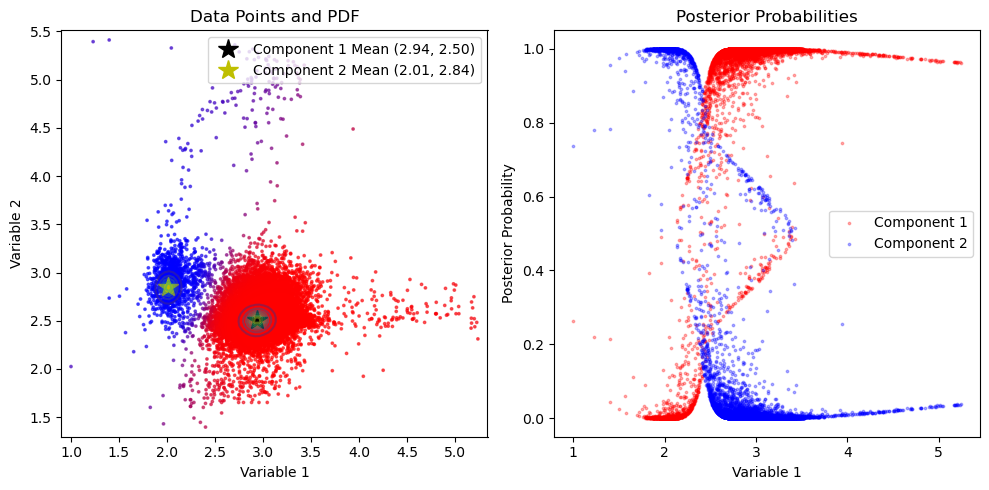

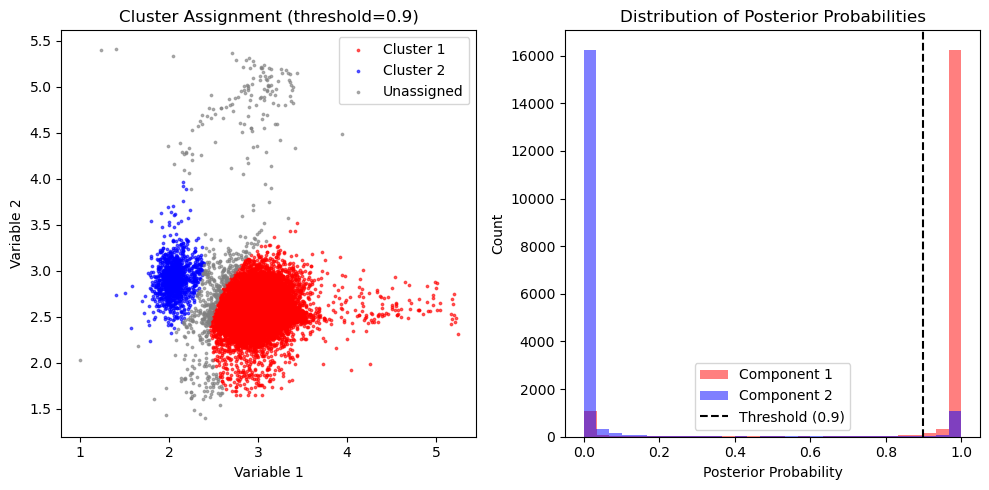

In [7]:
peaks = dm.find_density_peaks(X, n_peaks=2, bandwidth_factor=0.1) # KDE로 peak 2개 찾기
peaks_sorted = peaks[(-peaks[:, 0]).argsort()]  # x값 기준 내림차순 정렬
mu1_init, mu2_init = peaks_sorted[0], peaks_sorted[1]  # x값이 큰 것이 mu1_init (peak 2개를 초기값으로 사용)
fitted_params, cluster_labels, post_probs = dm.fit_and_visualize(X, mu1_init, mu2_init, threshold=0.9) # threshold는 적절히 조정

In [8]:
## fitting된 두 분포의 mean, cov, df, 둘간의 weight
## seed 고정이 아니어서 조금씩 달라질 수 있으니 주의
print('mean1',fitted_params[0:2], 'cov1:',fitted_params[2:5], 'df1:',fitted_params[5],'weight',fitted_params[12])
print('mean2',fitted_params[6:8], 'cov2:',fitted_params[8:11], 'df2:',fitted_params[11])

mean1 [2.93994608 2.50428589] cov1: [0.00941458 0.00039539 0.00664631] df1: 3.0 weight 0.6
mean2 [2.01493868 2.84470001] cov2: [0.00570116 0.00027838 0.00872944] df2: 3.0


In [9]:
## 클러스터 레이블을 데이터프레임에 추가
hdmlps_result = dm.add_cluster_labels_to_df(hdmlps, cluster_labels, column_name= 'cluster_09')

## 결과 확인
print("\nFirst few rows of the dataframe with clusters:")
print(hdmlps_result.head())


Cluster Assignment Summary:
Cluster 1: 16713 points (90.5%)
Cluster 2: 1189 points (6.4%)
Unassigned: 561 points (3.0%)

First few rows of the dataframe with clusters:
                          Combi.T.totalseq.C304  MC38.T.totalseq.C305  \
pool2_AAACCTGAGCTTTGGT-1               3.586475              2.450249   
pool2_AAACCTGAGGCATTGG-1               3.181558              2.472756   
pool2_AAACCTGAGGGTATCG-1               2.840106              2.468347   
pool2_AAACCTGAGTGGGTTG-1               2.996512              2.498311   
pool2_AAACCTGAGTTGAGAT-1               2.206826              2.924279   

                         cluster_09  
pool2_AAACCTGAGCTTTGGT-1  Cluster 1  
pool2_AAACCTGAGGCATTGG-1  Cluster 1  
pool2_AAACCTGAGGGTATCG-1  Cluster 1  
pool2_AAACCTGAGTGGGTTG-1  Cluster 1  
pool2_AAACCTGAGTTGAGAT-1  Cluster 2  


In [16]:
hdmlps_result

,Combi.T.totalseq.C304,MC38.T.totalseq.C305,cluster_09
pool2_AAACCTGAGCCACTAT-1,2.567026,2.471292,Cluster 1
pool2_AAACCTGAGCTTTGGT-1,3.586475,2.450249,Cluster 1
pool2_AAACCTGAGGCATTGG-1,3.181558,2.472756,Cluster 1
pool2_AAACCTGAGGGTATCG-1,2.840106,2.468347,Cluster 1
pool2_AAACCTGAGTGGGTTG-1,2.996512,2.498311,Cluster 1
...,...,...,...
pool2_TTTGTCATCGAGAGCA-1,3.129690,1.826075,Cluster 1
pool2_TTTGTCATCGCACTCT-1,2.822822,2.643453,Cluster 1
pool2_TTTGTCATCGCATGGC-1,2.763428,2.437751,Cluster 1
pool2_TTTGTCATCGGTCCGA-1,2.980003,2.544068,Cluster 1


## compare with manual annotation

In [11]:
hash_manual = pd.read_csv('/home/sjcho/projects/4-1BB/DA240060/outs/QC/3.demultiplexing/pool2_lower600_UMI2000_hash_manual.csv', index_col=0)

In [15]:
# cluster 정보 복사
df = hdmlps_result[['cluster_09']].copy()

# hash.manual 정보를 붙이기 (index 기준으로)
df['hash.manual'] = hash_manual.loc[df.index, 'hash.manual']

# confusion matrix 생성
conf_mat = pd.crosstab(df['cluster_09'], df['hash.manual'])

print(conf_mat)

hash.manual  Combi-T-totalseq-C304  MC38-T-totalseq-C305
cluster_09                                              
Cluster 1                    16713                     0
Cluster 2                        0                  1189
Unassigned                     414                   147


## Compare with HTO demultiplexing

In [13]:
HTO_demux = pd.read_csv('/home/sjcho/projects/4-1BB/DA240060/outs/QC/3.demultiplexing/pool2_lower600_UMI2000_HTOdemux.csv', index_col=0)

In [24]:
HTO_demux

,hashtag_classification
pool2_AAACCTGAGCCACTAT-1,Negative
pool2_AAACCTGAGCTTTGGT-1,Combi-T-totalseq-C304
pool2_AAACCTGAGGCATTGG-1,Combi-T-totalseq-C304
pool2_AAACCTGAGGGTATCG-1,Negative
pool2_AAACCTGAGTGGGTTG-1,Negative
...,...
pool2_TTTGTCATCGAGAGCA-1,Combi-T-totalseq-C304
pool2_TTTGTCATCGCACTCT-1,Negative
pool2_TTTGTCATCGCATGGC-1,Negative
pool2_TTTGTCATCGGTCCGA-1,Negative


In [17]:
# Step 1: cluster 정보 복사
df = hdmlps_result[['cluster_09']].copy()

# Step 2: hdmlps에서 hash.manual 추가
df['hash.manual'] = hash_manual.loc[df.index, 'hash.manual']

# Step 3: HTO_demux에서 hashtag_classification 추가
df['hashtag_classification'] = HTO_demux.loc[df.index, 'hashtag_classification']

# Step 4: confusion matrix 생성 (cluster vs hashtag classification)
conf_mat = pd.crosstab(df['cluster_09'], df['hashtag_classification'])

# 보기 좋게 이름 설정
conf_mat.index.name = 'Cluster'
conf_mat.columns.name = 'Hashtag'

print(conf_mat)

Hashtag     Combi-T-totalseq-C304  Combi-T-totalseq-C304_MC38-T-totalseq-C305  \
Cluster                                                                         
Cluster 1                    2632                                         623   
Cluster 2                       0                                           0   
Unassigned                      0                                          32   

Hashtag     MC38-T-totalseq-C305  Negative  
Cluster                                     
Cluster 1                   1746     11712  
Cluster 2                    983       206  
Unassigned                   283       246  


In [26]:
# Step 1: cluster 정보 복사
df = hdmlps_result[['cluster_09']].copy()

# Step 2: hdmlps에서 hash.manual 추가
df['hash.manual'] = hdmlps.loc[df.index, 'hash.manual']

# Step 3: HTO_demux에서 hashtag_classification 추가
df['hashtag_classification'] = HTO_demux.loc[df.index, 'hashtag_classification']

# Step 4: confusion matrix 생성 (cluster vs hashtag classification)
conf_mat = pd.crosstab(df['hash.manual'], df['hashtag_classification'])

# 보기 좋게 이름 설정
conf_mat.index.name = 'Cluster'
conf_mat.columns.name = 'Hashtag'

print(conf_mat)

Hashtag                Combi-T-totalseq-C304  \
Cluster                                        
Combi-T-totalseq-C304                   3239   
MC38-T-totalseq-C305                       0   

Hashtag                Combi-T-totalseq-C304_MC38-T-totalseq-C305  \
Cluster                                                             
Combi-T-totalseq-C304                                         823   
MC38-T-totalseq-C305                                            0   

Hashtag                MC38-T-totalseq-C305  Negative  
Cluster                                                
Combi-T-totalseq-C304                  1961     12573  
MC38-T-totalseq-C305                   1138       465  


In [13]:
## 결과 저장
hdmlps_result.to_csv('/home/sjcho/projects/4-1BB/DA240060/outs/QC/3.demultiplexing/hdmlps_result_pool2_thr09.csv')